# GBDT：串行树如何通过纠正残差逼近最优解

Gradient Boosting Decision Tree (GBDT) 的核心思想：**每一棵新树都在纠正前面所有树的残差**。

与随机森林的并行 Bagging 不同，GBDT 采用串行训练——后一棵树以前一棵树的误差为目标，逐步逼近最优解。这种策略主要降低**偏差**而非方差。

## 算法要点
- 基学习器：浅层回归树（max_depth=3），使用 MSE 选择切分点
- 串行训练：第 $t$ 棵树拟合前 $t-1$ 棵树的残差 $y - F_{t-1}(x)$
- 学习率（shrinkage）：每棵树的贡献乘以 lr，防止过拟合
- 从梯度视角看：拟合残差 = 梯度下降 in function space

我们使用加州房价数据集（California Housing）做回归 Demo。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor as SkGBDT
from sklearn.metrics import mean_squared_error, r2_score

import sys, os
sys.path.insert(0, os.path.abspath('..'))
from models.gradient_boosting import GBDTRegressor

# 中文字体配置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

## 1. 加载数据

我们使用加州房价数据集，随机抽取 2000 条作为训练集、500 条作为测试集，以便快速迭代。


In [2]:
# 加载 California Housing
housing = fetch_california_housing()
X, y = housing.data, housing.target
feature_names = housing.feature_names

# 混合后抽取子集
idx = np.random.RandomState(42).permutation(len(X))
X, y = X[idx], y[idx]

X_train, X_test, y_train, y_test = train_test_split(
    X[:3000], y[:3000], test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features: {feature_names}")


Train: (2400, 8), Test: (600, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## 2. 基线模型：单棵决策树

单棵深度受限的决策树效果有限，作为弱学习器的基线。


In [3]:
dt = DecisionTreeRegressor(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
rmse_dt = mean_squared_error(y_test, y_pred_dt) ** 0.5
r2_dt = r2_score(y_test, y_pred_dt)
print(f"DecisionTree (depth=3)  RMSE: {rmse_dt:.4f}  R²: {r2_dt:.4f}")


DecisionTree (depth=3)  RMSE: 0.7668  R²: 0.5492


## 3. 训练我们的 GBDT

使用默认参数：100 棵树、学习率 0.1、每棵树深度 3。


In [4]:
gbdt = GBDTRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
gbdt.fit(X_train, y_train)
y_pred_gbdt = gbdt.predict(X_test)
rmse_gbdt = mean_squared_error(y_test, y_pred_gbdt) ** 0.5
r2_gbdt = r2_score(y_test, y_pred_gbdt)
print(f"Our GBDT (100 trees)    RMSE: {rmse_gbdt:.4f}  R²: {r2_gbdt:.4f}")


Our GBDT (100 trees)    RMSE: 0.5671  R²: 0.7534


## 4. 训练过程：损失随树数量下降

绘制训练集 MSE 随树数量增加的变化曲线——可以看到 GBDT 如何逐步逼近最优解。


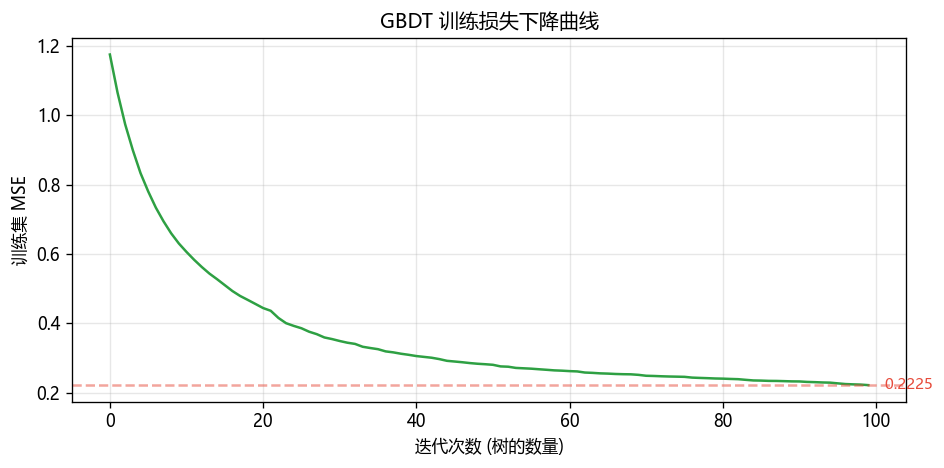

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(gbdt.train_loss_, color='#2ea043', lw=1.5)
plt.xlabel('迭代次数 (树的数量)')
plt.ylabel('训练集 MSE')
plt.title('GBDT 训练损失下降曲线')
plt.grid(alpha=0.3)
# 添加一条参考线表示最终损失
plt.axhline(y=gbdt.train_loss_[-1], color='#e74c3c', ls='--', alpha=0.5)
plt.text(len(gbdt.train_loss_), gbdt.train_loss_[-1],
         f'  {gbdt.train_loss_[-1]:.4f}', va='center', fontsize=9, color='#e74c3c')
plt.tight_layout()
plt.savefig('day6_loss_curve.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. 学习率的影响

学习率控制每棵树的贡献幅度。太大容易过拟合，太小需要更多树。


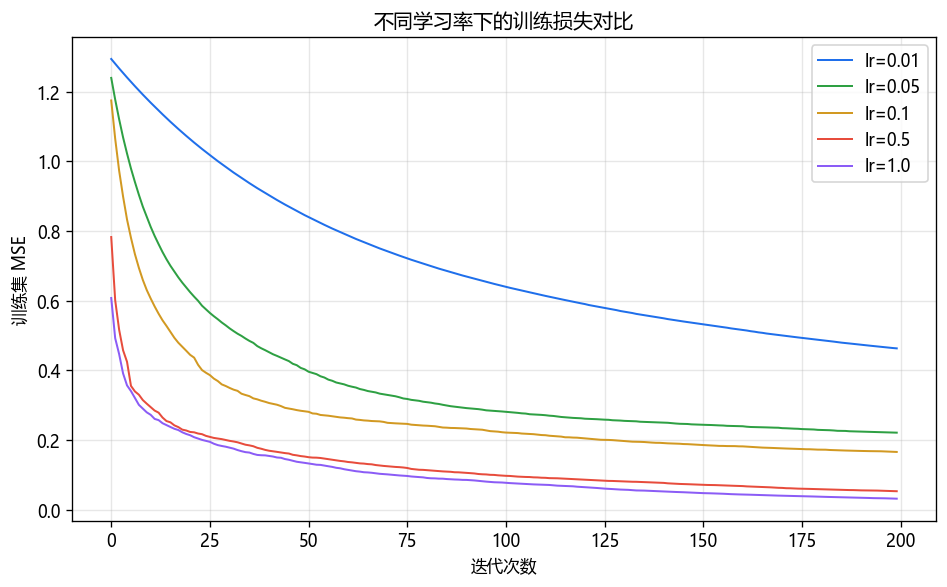

学习率与测试 RMSE 对比:
  lr=0.01  →  RMSE=0.6936
  lr=0.05  →  RMSE=0.5604
  lr=0.10  →  RMSE=0.5515
  lr=0.50  →  RMSE=0.6078
  lr=1.00  →  RMSE=0.6936


In [6]:
lrs = [0.01, 0.05, 0.1, 0.5, 1.0]
colors = ['#1f6feb', '#2ea043', '#d29922', '#e74c3c', '#8b5cf6']
results = []

plt.figure(figsize=(8, 5))
for lr, c in zip(lrs, colors):
    m = GBDTRegressor(n_estimators=200, learning_rate=lr, max_depth=3)
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    results.append((lr, rmse))
    plt.plot(m.train_loss_, label=f'lr={lr}', color=c, lw=1.2)

plt.xlabel('迭代次数')
plt.ylabel('训练集 MSE')
plt.title('不同学习率下的训练损失对比')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('day6_lr_compare.png', dpi=120, bbox_inches='tight')
plt.show()

print("学习率与测试 RMSE 对比:")
for lr, rmse in results:
    print(f"  lr={lr:.2f}  →  RMSE={rmse:.4f}")


## 6. 特征重要性

统计所有树中各特征被选为切分点的次数（加权 Gini 下降），了解哪些特征对预测贡献最大。


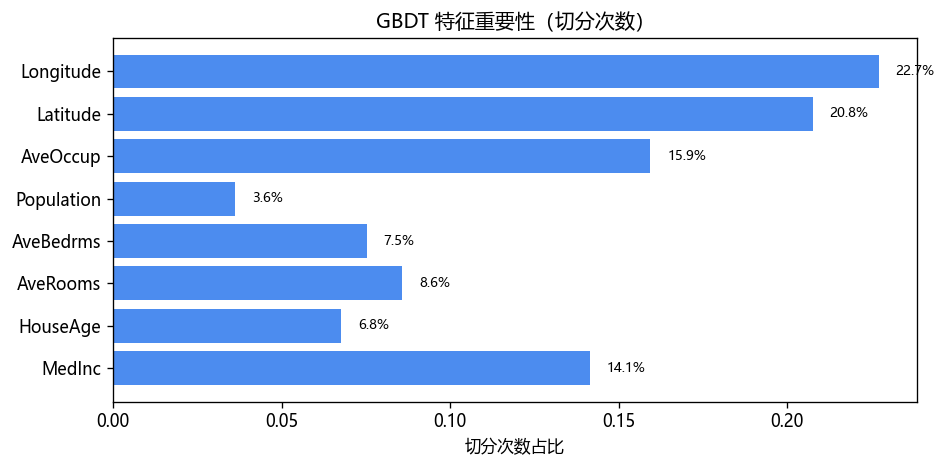

In [7]:
# 统计所有树中每个特征作为切分点的次数
importances = np.zeros(X_train.shape[1])
for tree in gbdt.trees_:
    def count_splits(node):
        if 'feature_idx' in node:
            importances[node['feature_idx']] += 1
            count_splits(node['left'])
            count_splits(node['right'])
    count_splits(tree.tree_)

# 归一化
importances = importances / importances.sum()

plt.figure(figsize=(8, 4))
bars = plt.barh(feature_names, importances, color='#1f6feb', alpha=0.8)
plt.xlabel('切分次数占比')
plt.title('GBDT 特征重要性（切分次数）')
# 添加数值标签
for bar, v in zip(bars, importances):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{v:.1%}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('day6_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


## 7. 最终对比

将我们的 GBDT 与 sklearn 官方实现对比，验证正确性。


模型                                  RMSE     R²      
---------------------------------------------------
DecisionTree (depth=3)              0.7668   0.5492  
Our GBDT (100 trees)                0.5671   0.7534  
sklearn GBDT (100 trees)            0.5733   0.7480  


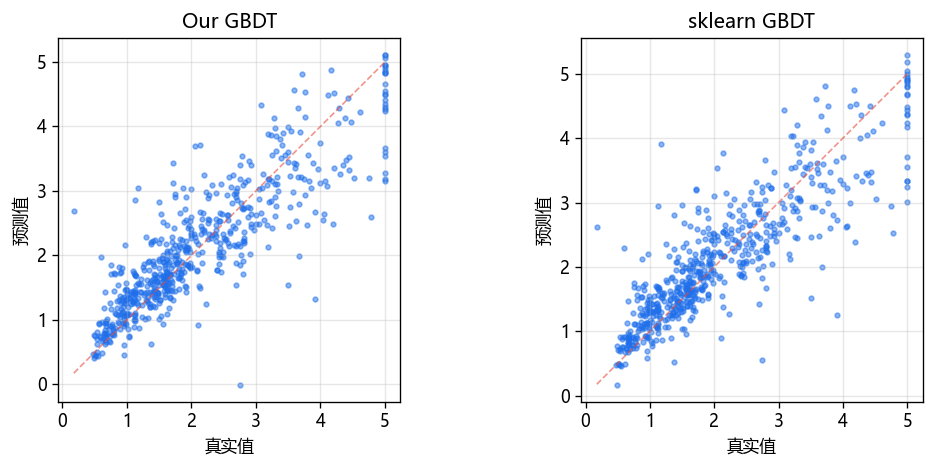

In [8]:
# sklearn 参考实现
sk_gbdt = SkGBDT(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
sk_gbdt.fit(X_train, y_train)
y_pred_sk = sk_gbdt.predict(X_test)
rmse_sk = mean_squared_error(y_test, y_pred_sk) ** 0.5
r2_sk = r2_score(y_test, y_pred_sk)

print(f"{'模型':<35} {'RMSE':<8} {'R²':<8}")
print("-" * 51)
print(f"{'DecisionTree (depth=3)':<35} {rmse_dt:<8.4f} {r2_dt:<8.4f}")
print(f"{'Our GBDT (100 trees)':<35} {rmse_gbdt:<8.4f} {r2_gbdt:<8.4f}")
print(f"{'sklearn GBDT (100 trees)':<35} {rmse_sk:<8.4f} {r2_sk:<8.4f}")

# 散点图：预测值 vs 真实值
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (name, y_pred) in zip(axes, [
    ('Our GBDT', y_pred_gbdt),
    ('sklearn GBDT', y_pred_sk),
]):
    ax.scatter(y_test, y_pred, s=8, alpha=0.5, color='#1f6feb')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            '--', color='#e74c3c', lw=1, alpha=0.6)
    ax.set_xlabel('真实值')
    ax.set_ylabel('预测值')
    ax.set_title(name)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('day6_pred_vs_true.png', dpi=120, bbox_inches='tight')
plt.show()


## 小结

- **单棵决策树**（depth=3）只能捕捉粗粒度模式，RMSE 较高
- **GBDT** 通过串行叠加浅层树、每棵拟合残差，逐步逼近目标
- 学习率控制步长，影响收敛速度和最终精度
- 特征重要性反映不同变量对预测的贡献度

GBDT 的核心洞察：**串行纠错 = 梯度下降 in function space**。
下一篇文章将介绍 XGBoost 如何在 GBDT 基础上进一步优化。
